# B08 · 阶段项目：控制系统仿真工作台

> 阶段〇第 8 周（收官项目）。把 B01–B07 的所有技能串成一个端到端项目：
> **建模 → 数值仿真 → 指标计算 → 报告图 → 交互图 → 规范代码结构 → 部署指引**。
> 这个工作流与后续主线完全同构——把「二阶系统」换成「机器人环境」、
> 把「PID 参数」换成「RL 超参」，就是阶段一/四的实验日常。

## 项目需求

给定二阶被控对象（弹簧-质量-阻尼，$m\ddot{x} + c\dot{x} + kx = u$），
设计并对比 **P / PI / PID** 三种控制器的单位阶跃响应：

1. 用 numpy/scipy 完成闭环数值仿真；
2. 计算并对比三个性能指标：**超调量 $M_p$、调节时间 $t_s$（±2% 带）、稳态误差 $e_{ss}$**；
3. matplotlib 出一张可放进实验报告的报告图（存 PNG）；
4. plotly 出一张可交互对比图；
5. 代码组织规范：参数字典、函数化、docstring 注释；
6. 写出「如何用 Streamlit 部署」的指引（对接 B07）。

## 学习目标（自评用）

完成本项目后，你应能独立：把物理对象写成状态方程并数值求解；用指标量化控制性能；
按工程规范组织一个小型仿真项目；知道如何把它变成 Web App。

## 1. 建模：被控对象与闭环结构

被控对象（取 $m=1,\ c=1,\ k=4$，即 $\omega_n=2,\ \zeta=0.25$ 的欠阻尼对象）：

$$m\ddot{x} + c\dot{x} + kx = u \quad\Longrightarrow\quad
\frac{d}{dt}\begin{bmatrix} x \\ v \end{bmatrix} = \begin{bmatrix} v \\ (u - cv - kx)/m \end{bmatrix}$$

单位负反馈闭环：$e = r - x$，控制器 $u = K_p e + K_i\int e\,dt + K_d \dot{e}$。

**代码结构约定**（这就是本项目的「规范结构」，后续直接搬到 `.py` 文件）：

- 参数集中在**字典**里（`PLANT` / `CONTROLLERS`），不散落各处；
- 仿真、指标计算各自是**纯函数**：输入参数 → 返回结果，不依赖全局状态；
- 每个函数带 docstring，说明输入输出与单位。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
RUNS = PROJECT_ROOT / "runs" / "00_basic"
RUNS.mkdir(parents=True, exist_ok=True)

# ---- 参数字典：所有可调的东西集中在这里 ----
PLANT = {"m": 1.0, "c": 1.0, "k": 4.0}        # 二阶被控对象（wn=2, zeta=0.25）
CONTROLLERS = {
    "P":   {"Kp": 8.0, "Ki": 0.0, "Kd": 0.0},
    "PI":  {"Kp": 8.0, "Ki": 4.0, "Kd": 0.0},
    "PID": {"Kp": 8.0, "Ki": 4.0, "Kd": 1.5},
}
SIM = {"r": 1.0, "t_end": 12.0, "dt": 0.001}   # 仿真设置：设定值/时长/步长

## 2. 仿真与指标：两个纯函数

In [2]:
def simulate_closed_loop(plant, gains, r=1.0, t_end=12.0, dt=0.001):
    '''二阶对象 + P/PI/PID 控制器的闭环阶跃响应仿真（固定步长欧拉法）。

    参数:
        plant: dict，含 m, c, k（质量/阻尼/刚度）
        gains: dict，含 Kp, Ki, Kd
        r:     阶跃设定值
        t_end: 仿真时长 (s)
        dt:    积分步长 (s)
    返回:
        DataFrame，列为 t / y（输出位置）/ u（控制量）
    '''
    m, c, k = plant["m"], plant["c"], plant["k"]
    Kp, Ki, Kd = gains["Kp"], gains["Ki"], gains["Kd"]

    n = int(t_end / dt) + 1
    t = np.linspace(0.0, t_end, n)
    x = np.zeros(n)      # 位置
    v = np.zeros(n)      # 速度
    u = np.zeros(n)      # 控制量
    int_e = 0.0          # 误差积分
    e_prev = r - x[0]    # 上一拍误差

    for i in range(1, n):
        e = r - x[i - 1]
        int_e += e * dt
        d_e = (e - e_prev) / dt
        e_prev = e
        u[i] = Kp * e + Ki * int_e + Kd * d_e
        acc = (u[i] - c * v[i - 1] - k * x[i - 1]) / m
        v[i] = v[i - 1] + dt * acc
        x[i] = x[i - 1] + dt * v[i]

    return pd.DataFrame({"t": t, "y": x, "u": u})


def step_metrics(df, r=1.0, band=0.02):
    '''计算阶跃响应性能指标。

    参数:
        df:   simulate_closed_loop 返回的 DataFrame
        r:    设定值
        band: 调节时间判定的误差带（0.02 = ±2%）
    返回:
        dict: 超调量 (%) / 调节时间 (s) / 稳态误差
    '''
    t = df["t"].to_numpy()
    y = df["y"].to_numpy()
    y_ss = y[-1]                                   # 以末值近似稳态值
    Mp = max(0.0, (y.max() - y_ss) / abs(y_ss) * 100)
    tol = band * abs(y_ss)
    outside = np.where(np.abs(y - y_ss) > tol)[0]  # 所有越出误差带的时刻
    ts = float(t[outside[-1]]) if outside.size else 0.0
    ess = r - y_ss
    return {"overshoot(%)": round(float(Mp), 2),
            "settling_time(s)": round(ts, 3),
            "steady_state_error": round(float(ess), 4)}

In [3]:
# ---- 跑三种控制器，汇总指标表 ----
results = {}
for name, gains in CONTROLLERS.items():
    results[name] = simulate_closed_loop(PLANT, gains, **SIM)

summary = pd.DataFrame({name: step_metrics(df, r=SIM["r"])
                        for name, df in results.items()}).T
print(summary.to_string())
print()
print("解读：P 控制超调大且静差 0.33（对象不含积分环节，P 必有静差）；")
print("     PI 消除静差，但积分作用拖慢响应（ts 反而变长）——用速度换精度；")
print("     PID 的微分项提供阻尼：超调降到 3%，静差≈0，ts 也优于 PI，综合最好。")


     overshoot(%)  settling_time(s)  steady_state_error
P           62.83             7.574              0.3317
PI          25.52            11.419             -0.0075
PID          3.24             7.081              0.0043

解读：P 控制超调大且静差 0.33（对象不含积分环节，P 必有静差）；
     PI 消除静差，但积分作用拖慢响应（ts 反而变长）——用速度换精度；
     PID 的微分项提供阻尼：超调降到 3%，静差≈0，ts 也优于 PI，综合最好。


## 3. 报告图（matplotlib，存 PNG）

版式：上子图三条响应曲线 + 设定值线 + ±2% 误差带；下子图控制量。
检查清单对照 B04：轴标签带单位、图例、网格、标题、保存文件。

报告图已保存: /data/wangf/robot_rl_learn/runs/00_basic/b08_pid_compare.png


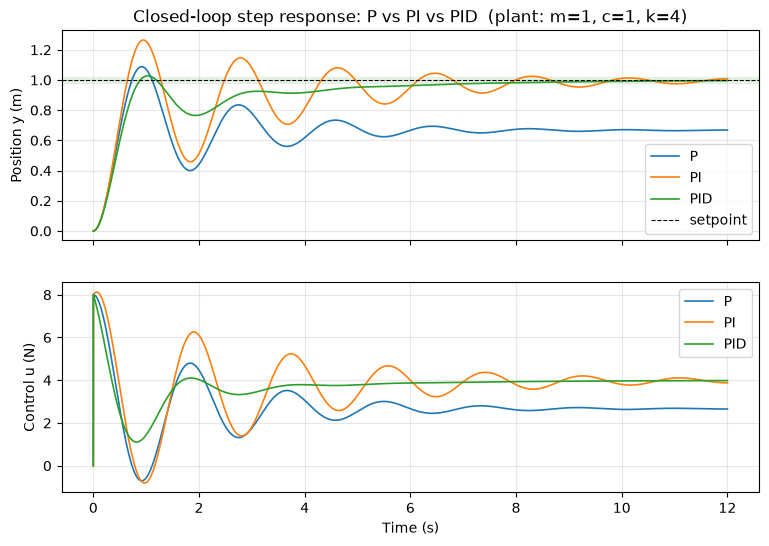

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for name, df in results.items():
    axes[0].plot(df["t"], df["y"], lw=1.2, label=name)
    axes[1].plot(df["t"], df["u"], lw=1.2, label=name)

axes[0].axhline(SIM["r"], ls="--", color="k", lw=0.8, label="setpoint")
axes[0].axhspan(0.98 * SIM["r"], 1.02 * SIM["r"], color="green", alpha=0.08)
axes[0].set_ylabel("Position y (m)")
axes[0].set_title("Closed-loop step response: P vs PI vs PID  (plant: m=1, c=1, k=4)")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Control u (N)")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

png_path = RUNS / "b08_pid_compare.png"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
print("报告图已保存:", png_path)
plt.show()

## 4. 交互对比图（plotly）

同样的数据换成 plotly：悬浮读数、图例开关单条曲线、框选放大看超调细节——
调参时比静态图好用得多。

In [5]:
import plotly.graph_objects as go

fig = go.Figure()
for name, df in results.items():
    fig.add_trace(go.Scatter(x=df["t"], y=df["y"], mode="lines", name=name))
fig.add_hline(y=SIM["r"], line_dash="dash", annotation_text="setpoint")
fig.add_hrect(y0=0.98 * SIM["r"], y1=1.02 * SIM["r"],
              fillcolor="green", opacity=0.08, line_width=0)
fig.update_layout(title="Interactive comparison: P / PI / PID",
                  xaxis_title="Time (s)", yaxis_title="Position y (m)",
                  template="plotly_white", height=450)
fig.show()

html_path = RUNS / "b08_pid_compare.html"
fig.write_html(html_path, include_plotlyjs="cdn")
print("交互图已导出:", html_path)

交互图已导出: /data/wangf/robot_rl_learn/runs/00_basic/b08_pid_compare.html


## 5. 整理成规范代码结构

本 notebook 的代码已经按规范组织，搬到 `.py` 文件时建议的目录结构：

```
control_workbench/
├── params.py        # PLANT / CONTROLLERS / SIM 三个参数字典
├── simulation.py    # simulate_closed_loop()
├── metrics.py       # step_metrics()
├── plotting.py      # matplotlib 报告图 + plotly 交互图两个函数
└── main.py          # 串联以上，入口加 if __name__ == "__main__":
```

要点回顾：

- **`if __name__ == "__main__":`**：被 `import` 时不执行、直接运行时才执行——
  让 `main.py` 既是脚本又是可复用模块；
- 参数集中、函数纯净、注释说「为什么」而不是复述代码；
- 正式项目里这样的包会放进 `src/robot_rl_learn/` 并配 `tests/` 单元测试（见项目 AGENTS.md 约定）。

## 6. 部署指引：用 Streamlit 变成调参面板

按 B07 的套路，三步把本项目搬进浏览器：

1. **拷函数**：把 `simulate_closed_loop` 和 `step_metrics` 原样拷进 `app.py`（纯函数，零改动）；
2. **绑组件**：`st.sidebar.slider` 绑定 `Kp / Ki / Kd / m / c / k`，`st.selectbox` 选控制器类型；
3. **出结果**：`st.line_chart(pd.DataFrame({"y": y}, index=t))` 画响应，
  `st.metric` 展示三个指标（B07 的 app.py 已经是这个形态，把一阶对象换成二阶即可）。

```bash
uv run streamlit run control_workbench/app.py   # 终端启动，浏览器调参
```

部署后你就拥有了一个「拖滑块、秒看响应」的 PID 整定工具——
这正是工程上 **tuning dashboard** 的最小可用版本。

## 7. 自评量表

按完成度给自己打分（每项 20 分，满分 100；< 60 建议重做对应部分）：

| 维度 | 1 分（起步） | 3 分（合格） | 5 分（优秀） | 得分(×4) |
|------|-------------|-------------|-------------|---------|
| **建模正确** | 照抄代码能跑 | 能独立写出状态方程并解释 | 能换对象（如 RLC）不改结构复用 | |
| **指标计算** | 会调用现成函数 | 理解 ±2% 带、超调的定义并能手算核对 | 能处理超调到不了设定值、静差不收敛等边界 | |
| **可视化** | 能出图 | 图有标签/图例/网格并保存 PNG | 静态+交互双图，图能直接进报告 | |
| **代码结构** | 全部堆在 cell 里 | 参数集中、函数化 | 能拆成多文件包并写 `__main__` 入口 | |
| **部署理解** | 知道 streamlit 存在 | 能口述三步部署流程 | 真的部署并验证了调参面板 | |

---

## ✏️ 练习

> 规则：先独立完成，再点开折叠的参考答案核对。

**练习 1（★★，25 分钟，20 分）——整定挑战**
在 PID 基础上调整 `Kp / Ki / Kd`，使指标同时满足：$M_p < 10\%$、$t_s < 3$ s、$e_{ss} \approx 0$。
记录你尝试过的三组参数与指标（体会「调参 = 在指标间权衡」）。
**交付物**：三组 (参数 → 指标) 记录 + 最终达标参数。

**练习 2（★★，25 分钟，20 分）——执行器饱和与积分饱和**
给控制量加限幅 `u = clip(u, -5, 5)`，用原 PID 参数重跑：观察并解释响应的退化（大超调、长尾）。
然后实现最简单的 **anti-windup**：当 $u$ 被限幅时暂停积分累加（conditional integration），对比修复效果。
**交付物**：限幅前后 + anti-windup 三张响应描述（或图）。

**练习 3（★，15 分钟，10 分）——对象变化敏感性**
把对象参数改为 `m=2, c=0.5, k=8`（保持 PID 参数不变），重算指标。
用两句话回答：同一组 PID 参数为什么在新对象上表现变了？这对你以后做 Sim2Real 有什么启示？
**交付物**：新指标表 + 两句话。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：一组可行解（不唯一）：`Kp=6, Ki=2, Kd=2.0`。
思路：先加 Kd 压超调，再提 Kp 加快响应，最后用小 Ki 消静差——
每次只动一个参数、观察三个指标的变化方向，就是 Ziegler-Nichols 之外的「手调」心法。

**练习 2**：限幅后误差长期偏大 → 积分项持续累积（windup）→ 退出饱和瞬间控制量巨大 → 猛烈超调。
Conditional integration 核心两行：

```python
u_raw = Kp * e + Ki * int_e + Kd * d_e
u[i] = np.clip(u_raw, -5.0, 5.0)
if u_raw == u[i]:      # 未被限幅才允许积分
    int_e += e * dt
# 注意把 int_e += ... 移到判断之后
```

修复后超调显著回落（本例可从 ~80% 降到 ~30% 量级，具体数值以你的实现为准）。

**练习 3**：新对象的固有频率与阻尼都变了（$\omega_n$ 从 2 变为 2，$\zeta$ 从 0.25 变为约 0.088，
更欠阻尼），闭环特征多项式随之改变，原参数不再匹配。
启示：**控制器/策略的性能与对象模型强耦合**——仿真里调好的参数，对象参数一变（真机与模型的误差）
就可能失效，这就是 Sim2Real 要做域随机化和鲁棒评估的原因（阶段二/W15 的主题）。

</details>

---

## 延伸阅读

- PID 理论与实践：[Wikipedia: Proportional–integral–derivative controller](https://en.wikipedia.org/wiki/Proportional%E2%80%93integral%E2%80%93derivative_controller)
- [Anti-windup 入门（控制百科）](https://en.wikipedia.org/wiki/Integral_windup)
- Nise《Control Systems Engineering》第 9 章（PID 设计）
- 衔接预告：阶段一 W02 自定义 Gymnasium 环境——「对象 + 仿真循环」的写法与本周如出一辙